# GLMsingle cue-locked vs feedback-locked betas — how redundant are they?

Aggregates the per-subject CSVs written by `compare_cue_vs_feedback_betas.py` and answers one
question: **how much of the feedback-locked betas (`derivatives/glmsingle_feedback/`) is
genuinely new relative to the cue-locked betas (`derivatives/glmsingle/`)?**

`run_glmsingle_feedback.py` predicts, from timing alone, that the answer is "not much".
Feedback onset is only **1.95 s after cue onset (SD 0.16 s)** and TR is 2.334 s, so 82.4% of
feedback events land exactly 1 TR after their cue's TR and 17.5% land in the *same* TR — leaving
~0.16 s of RT jitter to deconvolve with. This notebook measures whether that prediction holds.

## Why baselines are mandatory here

A bare correlation between two beta sets is close to meaningless: every beta map shares a large
common spatial structure, so even unrelated trials correlate. Two baselines are therefore
computed alongside every measure:

| baseline | what it is | what it tells you |
|---|---|---|
| **shuffled** | feedback trial *t* vs a random **different** cue trial in the same run, averaged over 10 draws | the floor — correlation from shared structure alone |
| **adjacent** | cue trial *k* vs cue trial *k+1*, same run | what ordinary temporal proximity already buys |

Read the result as:

- `matched ≈ shuffled` → no trial-specific coupling beyond shared spatial structure
- `matched ≫ adjacent` → the feedback betas are largely redundant with the cue betas

## Two measures

- **Voxelwise temporal r** — per voxel, cue vs feedback across matched trials. The headline.
- **Trialwise spatial r** — per trial, across voxels, on voxel-demeaned betas (without the
  demeaning this is dominated by the mean response pattern every trial shares).

## Two model types

Type **D** is the production beta every downstream analysis uses, but a type-D-only comparison is
confounded for *this* question: D's GLMdenoise PC count and fracridge fraction are cross-validated
over **condition repeats**, and the two models define conditions differently (8 stimulus
identities for cue, 8 stimulus pairs for feedback). So D alone mixes different event timing with
different hyperparameter selection. Type **B** (FITHRF only, no denoise, no ridge) isolates the
timing effect. Type A is unavailable — ONOFF pools every event into one beta, leaving nothing
per-trial to correlate.


## Reproducing the inputs

The per-subject CSVs come from the cluster run:

```bash
# 1. estimate both beta sets (if not already done)
bash multivariate/submit_glmsingle.sh              # -> derivatives/glmsingle/
bash multivariate/submit_glmsingle_feedback.sh     # -> derivatives/glmsingle_feedback/

# 2. compare them, types B and D (the submit script's default)
bash multivariate/submit_compare_cue_vs_feedback.sh
#    -> derivatives/cue_vs_feedback/sub-*/sub-*_cue_vs_feedback.csv

# 3. pull the CSVs down to the path in CVF_DIR below (~236 KB)
rsync -a --include='sub-*/' --include='sub-*_cue_vs_feedback.csv' --exclude='*' \
  uzh.cluster.cmd:/home/hfluhr/shares-hare/ds-learning-habits/derivatives/cue_vs_feedback/ \
  <CVF_DIR>/
```

Every number below is derived from those CSVs alone — nothing here re-reads the beta images.


In [1]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directory holding the per-subject sub-*/sub-*_cue_vs_feedback.csv files
# (the --output-dir passed to compare_cue_vs_feedback_betas.py). Edit for your filesystem.
CVF_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/"
               "bids_dataset/derivatives/cue_vs_feedback")

BETA_ORDER  = ["B", "D"]
BETA_LABELS = {"B": "B (+FITHRF)", "C": "C (+GLMdenoise)", "D": "D (+ridge)"}
MASK_ORDER  = ["wholebrain", "visualcortex"]

# Categorical palette, fixed slot order (validated for both light and dark surfaces).
# Series colour follows the entity, never its rank, so these stay pinned to the
# measure they name regardless of what gets plotted.
C_MATCHED  = "#2a78d6"   # slot 1, blue
C_ADJACENT = "#eb6834"   # slot 2, orange
C_SHUFFLED = "#1baf7a"   # slot 3, aqua
INK, INK_MUTED, GRID = "#1a1a19", "#6b6a63", "#d9d8d2"

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "grid.color": GRID, "grid.linewidth": 0.6, "font.size": 9,
})


In [2]:
csvs = sorted(glob.glob(str(CVF_DIR / "sub-*" / "sub-*_cue_vs_feedback.csv")))
assert csvs, f"No comparison CSVs found under {CVF_DIR}"

df = pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True)
df["subject"]   = df["subject"].astype(str).str.zfill(2)
df["beta_type"] = pd.Categorical(df["beta_type"], categories=BETA_ORDER, ordered=True)

print(f"{df['subject'].nunique()} subjects | beta types: {sorted(df['beta_type'].unique())} "
      f"| masks: {sorted(df['mask'].unique())}")
print(f"trials per subject: min {df['n_trials'].min()}, median {int(df['n_trials'].median())}, "
      f"max {df['n_trials'].max()}")
df.head(4)


59 subjects | beta types: ['B', 'D'] | masks: ['visualcortex', 'wholebrain']
trials per subject: min 176, median 189, max 192


,subject,beta_type,mask,n_voxels,n_trials,vox_r_matched_median,vox_r_matched_q25,vox_r_matched_q75,vox_r_shuffled_median,vox_r_adjacent_median,trial_r_matched_mean,trial_r_matched_sd,trial_r_shuffled_mean,trial_r_adjacent_mean,trial_r_matched_raw_mean
0,01,B,wholebrain,65480,187,0.399217,0.283036,0.491271,0.001615,0.212088,0.025216,0.033526,0.000262,0.371647,0.027521
1,01,B,visualcortex,7570,187,0.432989,0.335715,0.516569,0.008541,0.199722,0.293768,0.364813,-0.008810,0.389448,0.287924
2,01,D,wholebrain,65480,187,0.368476,0.264298,0.460869,-0.004584,0.007218,0.024831,0.045039,-0.000343,0.022733,0.023445
3,01,D,visualcortex,7570,187,0.377121,0.283335,0.466001,0.000413,0.031300,0.301733,0.344279,-0.002571,0.186252,0.278376


## 1. Group summary

Matched correlation against both baselines, per beta type and mask. The shuffled column is the
one to check first: if it is not ~0, the whole comparison is invalid.


In [3]:
def summarise(d):
    return pd.Series({
        "n":               d["subject"].nunique(),
        "matched median":  d["vox_r_matched_median"].median(),
        "matched q25":     d["vox_r_matched_median"].quantile(.25),
        "matched q75":     d["vox_r_matched_median"].quantile(.75),
        "matched min":     d["vox_r_matched_median"].min(),
        "matched max":     d["vox_r_matched_median"].max(),
        "shuffled":        d["vox_r_shuffled_median"].median(),
        "adjacent":        d["vox_r_adjacent_median"].median(),
        "trialwise":       d["trial_r_matched_mean"].median(),
    })

summary = (df.groupby(["beta_type", "mask"], observed=True)
             .apply(summarise, include_groups=False)
             .reindex(pd.MultiIndex.from_product([BETA_ORDER, MASK_ORDER],
                                                 names=["beta_type", "mask"])))
print("Voxelwise r (cue vs feedback), per-subject medians aggregated across subjects\n")
display(summary.round(3))

# Sanity gate: the shuffled floor must be ~0 in every cell, otherwise the
# voxel-demeaning or the trial alignment is wrong and nothing below means anything.
worst = df["vox_r_shuffled_median"].abs().max()
print(f"\nlargest |shuffled| across all subjects/types/masks: {worst:.4f}  "
      f"-> {'OK' if worst < 0.05 else 'FAIL — investigate before reading on'}")


Voxelwise r (cue vs feedback), per-subject medians aggregated across subjects



n  matched median  matched q25  matched q75  \
beta_type mask                                                           
B         wholebrain    59.0           0.782        0.470        0.818   
          visualcortex  59.0           0.810        0.494        0.847   
D         wholebrain    59.0           0.773        0.438        0.802   
          visualcortex  59.0           0.778        0.442        0.806   

                        matched min  matched max  shuffled  adjacent  \
beta_type mask                                                         
B         wholebrain          0.090        0.867    -0.000     0.213   
          visualcortex        0.072        0.902     0.005     0.242   
D         wholebrain          0.002        0.865    -0.005     0.050   
          visualcortex        0.038        0.865    -0.003     0.089   

                        trialwise  
beta_type mask                     
B         wholebrain        0.218  
          visualcortex      0.538  
D         wholebrain        0.233  
          visualcortex      0.539


largest |shuffled| across all subjects/types/masks: 0.0326  -> OK


## 2. Every subject against its own baselines

One row per subject, sorted by matched *r*. The gap between the blue points and the two baseline
series is the whole result: everything above the baselines is genuine trial-by-trial coupling
between the cue and feedback betas.


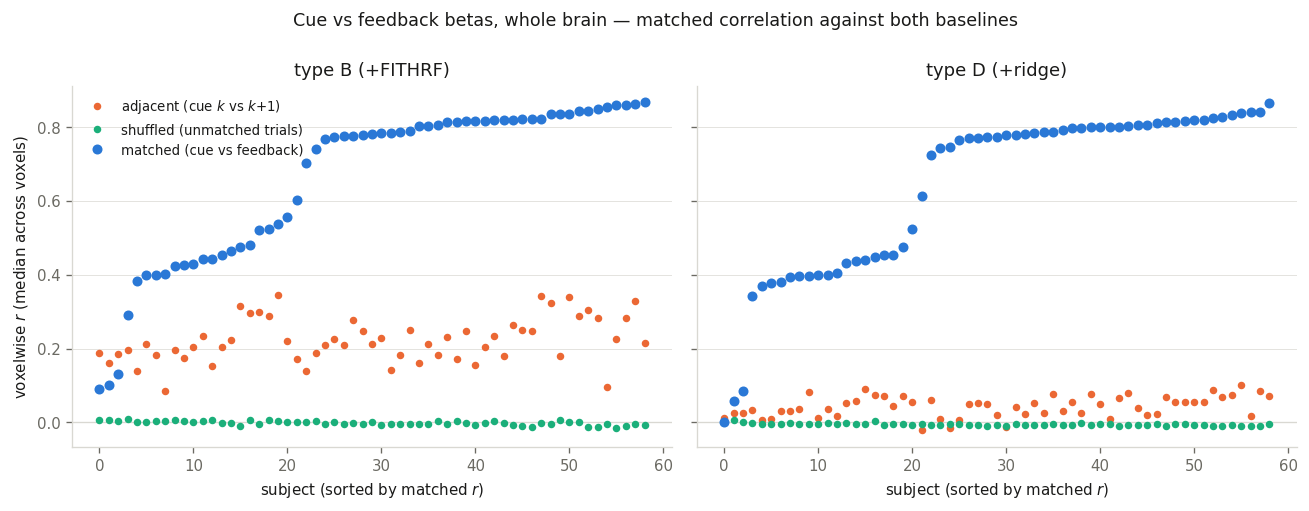

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)

for ax, bt in zip(axes, BETA_ORDER):
    d = (df[(df.beta_type == bt) & (df["mask"] == "wholebrain")]
         .sort_values("vox_r_matched_median").reset_index(drop=True))
    x = np.arange(len(d))
    ax.axhline(0, color=GRID, lw=0.8, zorder=1)
    ax.plot(x, d["vox_r_adjacent_median"], "o", ms=3.5, color=C_ADJACENT,
            label="adjacent (cue $k$ vs $k{+}1$)", zorder=2)
    ax.plot(x, d["vox_r_shuffled_median"], "o", ms=3.5, color=C_SHUFFLED,
            label="shuffled (unmatched trials)", zorder=3)
    ax.plot(x, d["vox_r_matched_median"], "o", ms=5, color=C_MATCHED,
            label="matched (cue vs feedback)", zorder=4)
    ax.set_title(f"type {BETA_LABELS[bt]}", color=INK)
    ax.set_xlabel("subject (sorted by matched $r$)")
    ax.grid(axis="y", alpha=0.7)
    ax.set_axisbelow(True)

axes[0].set_ylabel("voxelwise $r$ (median across voxels)")
axes[0].legend(loc="upper left", frameon=False, fontsize=8)
fig.suptitle("Cue vs feedback betas, whole brain — matched correlation against both baselines",
             y=1.0, fontsize=10.5, color=INK)
fig.tight_layout()
plt.show()


## 3. The distribution is multimodal, not smooth

The sorted plot above has a visible step rather than a ramp. Binning makes it explicit — and the
same structure appears in type B, which has **no** GLMdenoise and **no** ridge. That rules out
divergent hyperparameter selection between the two models as the cause.


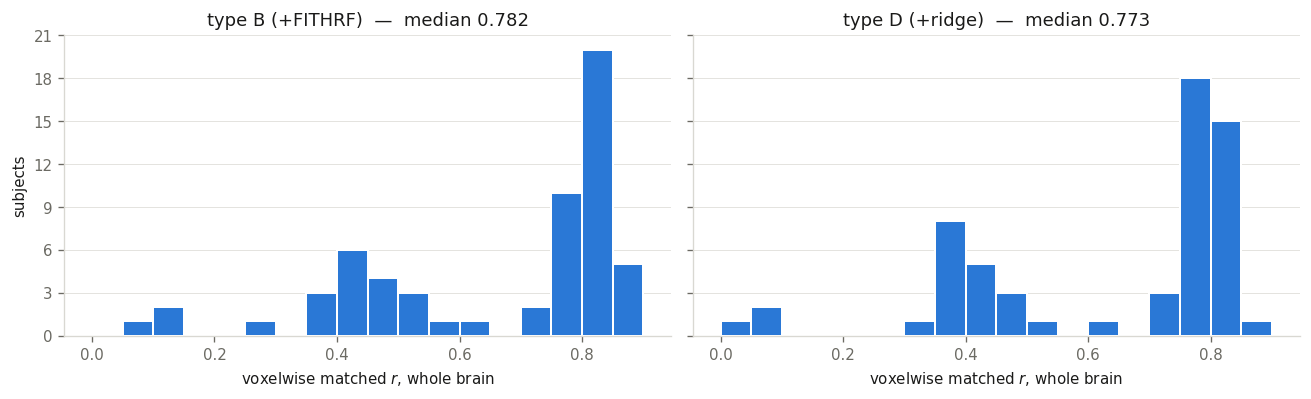

group sizes (defined on type D): {'near-zero': 3, 'low': 18, 'high': 38}

same subjects' r, by beta type — the split survives in B, which has no GLMdenoise and no ridge:


beta_type      B                    D              
          median    min    max median    min    max
D                                                  
near-zero  0.101  0.090  0.132  0.058  0.002  0.084
low        0.442  0.292  0.556  0.403  0.342  0.523
high       0.815  0.603  0.867  0.799  0.611  0.865

near-zero subjects: ['05', '28', '70']


In [5]:
from matplotlib.ticker import MaxNLocator

bins = np.arange(0, 0.95, 0.05)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True, sharex=True)

for ax, bt in zip(axes, BETA_ORDER):
    m = df[(df.beta_type == bt) & (df["mask"] == "wholebrain")]["vox_r_matched_median"]
    # surface-coloured edge = the 2px gap between adjacent bars
    ax.hist(m, bins=bins, color=C_MATCHED, edgecolor="white", linewidth=1.2)
    ax.set_title(f"type {BETA_LABELS[bt]}  —  median {m.median():.3f}", color=INK)
    ax.set_xlabel("voxelwise matched $r$, whole brain")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))  # subjects are countable
    ax.grid(axis="y", alpha=0.7)
    ax.set_axisbelow(True)

axes[0].set_ylabel("subjects")
fig.tight_layout()
plt.show()

# Group membership, defined on type D and checked against type B
piv = (df[df["mask"] == "wholebrain"]
       .pivot(index="subject", columns="beta_type", values="vox_r_matched_median"))
groups = pd.cut(piv["D"], [-1, 0.10, 0.55, 1.0], labels=["near-zero", "low", "high"])
print("group sizes (defined on type D):", groups.value_counts().reindex(
    ["near-zero", "low", "high"]).to_dict())
print("\nsame subjects' r, by beta type — the split survives in B, which has no "
      "GLMdenoise and no ridge:")
display(piv.groupby(groups, observed=True).agg(["median", "min", "max"]).round(3))
print("near-zero subjects:", sorted(piv.index[groups == "near-zero"].tolist()))


## 4. Does the choice of beta type matter? Does the mask?

Two paired scatters. Left: type B vs type D — if the points sit on the identity line, the
GLMdenoise/ridge confound is not driving the result. Right: whole brain vs visual cortex — if
those also sit on the line, the between-subject spread is a **subject-level** property, not a
regional one.


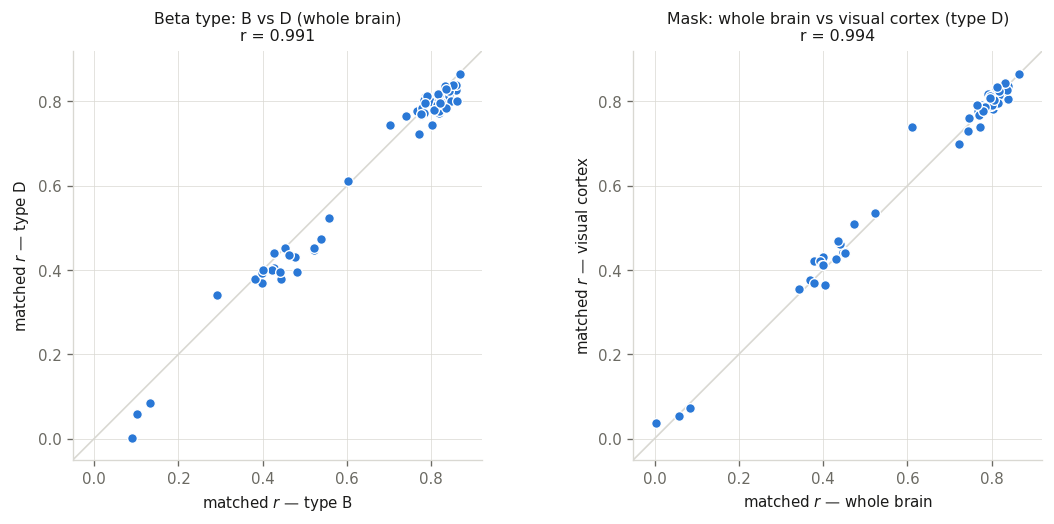

D - B  : median -0.020   mean -0.020   range [-0.088, +0.050]
corr(B, D) across subjects            : 0.991
corr(whole brain, visual cortex), D   : 0.994

adjacent baseline, median: type B 0.213   type D 0.050   <- GLMdenoise/ridge removes temporal autocorrelation between neighbouring trials


In [6]:
wb_vc = (df[df.beta_type == "D"]
         .pivot(index="subject", columns="mask", values="vox_r_matched_median"))

panels = [
    (piv["B"],           piv["D"],              "type B", "type D",
     "Beta type: B vs D (whole brain)"),
    (wb_vc["wholebrain"], wb_vc["visualcortex"], "whole brain", "visual cortex",
     "Mask: whole brain vs visual cortex (type D)"),
]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.4))
for ax, (xv, yv, xl, yl, title) in zip(axes, panels):
    lo, hi = -0.05, 0.92
    ax.plot([lo, hi], [lo, hi], "-", color=GRID, lw=1, zorder=1)
    # 2px surface ring on overlapping marks
    ax.scatter(xv, yv, s=34, color=C_MATCHED, edgecolor="white", linewidth=0.8, zorder=2)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    ax.set_xlabel(f"matched $r$ — {xl}"); ax.set_ylabel(f"matched $r$ — {yl}")
    ax.set_title(f"{title}\nr = {xv.corr(yv):.3f}", fontsize=9.5, color=INK)
    ax.grid(alpha=0.7); ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

delta = piv["D"] - piv["B"]
print(f"D - B  : median {delta.median():+.3f}   mean {delta.mean():+.3f}   "
      f"range [{delta.min():+.3f}, {delta.max():+.3f}]")
print(f"corr(B, D) across subjects            : {piv['B'].corr(piv['D']):.3f}")
print(f"corr(whole brain, visual cortex), D   : {wb_vc['wholebrain'].corr(wb_vc['visualcortex']):.3f}")
print(f"\nadjacent baseline, median: type B {df[(df.beta_type=='B') & (df['mask']=='wholebrain')]['vox_r_adjacent_median'].median():.3f}"
      f"   type D {df[(df.beta_type=='D') & (df['mask']=='wholebrain')]['vox_r_adjacent_median'].median():.3f}"
      "   <- GLMdenoise/ridge removes temporal autocorrelation between neighbouring trials")


## Findings summary

n = 59. Voxelwise *r*, whole brain, type D unless noted.

| | matched | shuffled | adjacent |
|---|---|---|---|
| **type B** | **0.782** (IQR 0.470–0.818) | −0.000 | 0.213 |
| **type D** | **0.773** (IQR 0.438–0.802) | −0.005 | 0.050 |

- **The prediction from timing is confirmed.** Matched correlation sits far above both baselines,
  and the shuffled floor is ~0 across every subject, type and mask (largest |shuffled| = 0.033).
  So this is genuine trial-by-trial coupling, not shared spatial structure. At *r* = 0.77 that is
  *r*² ≈ 0.60 shared variance.
- **And that is a lower bound, not an upper one.** Single-trial betas are noisy, and two noisy
  estimates of the *same* underlying quantity correlate at their reliability rather than at 1.
  There is no noise-ceiling estimate here, so true redundancy is higher than these numbers.
- **The beta-type confound is real in principle but negligible in practice.** corr(B, D) across
  subjects = 0.991, and D − B = −0.020 median. The condition definitions differ between the two
  models (stimulus identities vs stimulus pairs), but that does not meaningfully move the result.
- **The distribution is multimodal**: 38 subjects near 0.79, 18 near 0.42, 3 near zero
  (`sub-05`, `sub-28`, `sub-70`), with almost nothing between 0.10–0.30 or 0.55–0.70. **This is
  unexplained.** The natural hypothesis — divergent GLMdenoise/fracridge tuning between the two
  models — is ruled out, because the same split appears in type B, which has neither. Per-subject
  checks on `sub-05` also cleared data quality (it has the *highest* median cue R² of the first
  five checked), FRACvalue, HRF index, beta SD and noise-pool size.
- **The spread is subject-level, not regional**: corr(whole brain, visual cortex) = 0.994.
- **Incidental but informative**: the adjacent-trial baseline drops from 0.213 (B) to 0.050 (D),
  direct evidence that GLMdenoise/ridge removes real temporal autocorrelation between
  neighbouring trials.

**Consequence for the feedback betas.** For roughly two-thirds of the sample they largely
re-express the cue response. Combined with the separate finding that objective reward level is a
deterministic function of stimulus identity in this design, a reward-at-feedback analysis built
on these betas is unlikely to yield anything not already present in the cue betas.

**Open thread.** The multimodality is the most interesting unexplained result here. Candidates
not yet tested: per-subject head motion, the fitted HRF index *distribution* (rather than the
voxelwise agreement already checked), and whether the low group differs in RT variability — the
only thing that gives the two models any temporal separation to work with.
